# Exploración y caracterización de aforos vehiculares HMD

Issue #1 · Fase 1 - Comprensión del dominio y los datos · Semana 1 · Responsable: Samuel Campos

Exploración estadística descriptiva de la base de datos de aforos vehiculares en hora de máxima demanda (HMD).

Tareas:
1. Cargar el dataset y revisar estructura (columnas, tipos de datos)
2. Identificar valores faltantes y registros duplicados
3. Verificar consistencia temporal (fechas, horas, periodos)
4. Analizar distribución de conteos por punto de medición
5. Documentar hallazgos iniciales

## 1. Carga del dataset y revisión de estructura

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RAW_PATH = "../data/raw/a. Base de datos aforos hora de maxima demanda.xlsx"

xls = pd.ExcelFile(RAW_PATH)
xls.sheet_names

['PORTADA', 'CONTENIDO', 'DICC', 'BD']

El archivo tiene 4 hojas: `PORTADA` (portada, vacía), `CONTENIDO` (índice del documento), `DICC` (diccionario de datos) y `BD` (los datos de aforos propiamente dichos). Revisamos primero el diccionario de datos para entender cada campo antes de explorar `BD`.

In [2]:
dicc = pd.read_excel(RAW_PATH, sheet_name="DICC")
pd.set_option("display.max_colwidth", 120)
dicc

,Campo,Descripción,Rango o valores permitidos
0,Tipología,Se refiere a la categoría de la tipología vehicular aforada,Auto\nMoto\nBicicleta en calzada\nBicicleta en ciclorruta\nBRT\nEspecial ocupado\nMoto\nTaxi ocupado\nTPC intermunic...
1,ID,Identificador de la estación donde se realizo el aforo,"Estaciones de aforo de transporte privado, Bicicleta en ciclurruta, Transmilenio/Transmicable y Tranporte público de..."
2,Localización,Intersección del aforo,Dirección o punto de referencia de los aforos realizados
3,EODI,Intersección del aforo en donde se realizaron encuestas EODI,SI: se realizaron encuestas EODI\nNO: no se realizaron encuestas EODI
4,Periodo,Periodo de realización de la encuesta,AM: encuestas aplicadas en el período de la mañana (5:30 - 8:30)\nPM: encuestas aplicadas en el período de la tarde ...
5,Sentido,Dirección del tráfico,"Sentido cardinal en que circulaba el encuestado (N-S, S-N, W-E, E-W, ingreso)"
6,Volumen,Cantidad de vehículos por intersección,número de vehículos mixtos que pasan en la hora de máxima demanda


In [3]:
bd = pd.read_excel(RAW_PATH, sheet_name="BD")
print("Dimensiones:", bd.shape)
bd.dtypes

Dimensiones: (3956, 7)


TIPOLOGIA           str
ID                  str
LOCALIZACIÓN        str
EODI                str
PERIODO             str
SENTIDO             str
VOLUMEN         float64
dtype: object

In [4]:
bd.head(10)

,TIPOLOGIA,ID,LOCALIZACIÓN,EODI,PERIODO,SENTIDO,VOLUMEN
0,BICICLETA EN CICLORUTA,BC_3,AC 80 X KR 116A,SI,AM,E-W,1118.0
1,BICICLETA EN CICLORUTA,BC_3,AC 80 X KR 116A,SI,AM,W-E,583.5
2,BICICLETA EN CICLORUTA,BC_3,AC 80 X KR 116A,SI,PM,E-W,472.0
3,BICICLETA EN CICLORUTA,BC_3,AC 80 X KR 116A,SI,PM,W-E,932.0
4,BICICLETA EN CICLORUTA,BC_5,TV 60 X KR 104,SI,AM,N-S,539.0
5,BICICLETA EN CICLORUTA,BC_5,TV 60 X KR 104,SI,AM,S-N,743.5
6,BICICLETA EN CICLORUTA,BC_5,TV 60 X KR 104,SI,PM,N-S,867.0
7,BICICLETA EN CICLORUTA,BC_5,TV 60 X KR 104,SI,PM,S-N,418.5
8,BICICLETA EN CICLORUTA,BC_57,TV 86 X KR 91,SI,AM,N-S,4187.5
9,BICICLETA EN CICLORUTA,BC_57,TV 86 X KR 91,SI,AM,S-N,598.0


**Estructura de `BD`**: 3956 registros × 7 columnas.

| Columna | Tipo | Descripción |
|---|---|---|
| TIPOLOGIA | texto | Categoría del vehículo aforado (auto, moto, bici, BRT, TPC, etc.) |
| ID | texto | Identificador de la estación de aforo |
| LOCALIZACIÓN | texto | Intersección o punto de referencia del aforo |
| EODI | texto (SI/NO) | Si en esa intersección también se aplicaron encuestas EODI |
| PERIODO | texto (AM/PM) | Franja horaria: AM 5:30-8:30, PM 16:00-19:00 |
| SENTIDO | texto | Sentido cardinal del flujo (N-S, S-N, W-E, E-W, INGRESO) |
| VOLUMEN | numérico | Número de vehículos que pasan en la hora de máxima demanda |

No hay una columna de fecha explícita: la granularidad temporal del dataset se limita a `PERIODO` (AM/PM), no a fechas ni horas puntuales.

## 2. Valores faltantes y registros duplicados

In [5]:
bd.isna().sum()

TIPOLOGIA       0
ID              0
LOCALIZACIÓN    0
EODI            0
PERIODO         0
SENTIDO         0
VOLUMEN         0
dtype: int64

No hay valores nulos en ninguna columna.

In [6]:
duplicados = bd[bd.duplicated(keep=False)].sort_values(list(bd.columns))
print(f"Filas totalmente duplicadas: {bd.duplicated().sum()}")
duplicados

Filas totalmente duplicadas: 3


,TIPOLOGIA,ID,LOCALIZACIÓN,EODI,PERIODO,SENTIDO,VOLUMEN
3890,BRT,TM_53,Alquería,SI,AM,INGRESO,781.666667
3891,BRT,TM_53,Alquería,SI,AM,INGRESO,781.666667
3901,BRT,TM_6,Portal del Tunal,SI,AM,INGRESO,7337.666667
3902,BRT,TM_6,Portal del Tunal,SI,AM,INGRESO,7337.666667
3932,BRT,TM_8,Portal de Usme,SI,AM,INGRESO,7153.333333
3933,BRT,TM_8,Portal de Usme,SI,AM,INGRESO,7153.333333


Hay 3 pares de filas exactamente duplicadas, todas en registros `BRT` (TM_53, TM_6, TM_8), mismo periodo (AM) y mismo sentido (INGRESO). Es probable que sean errores de digitación al consolidar la base (fila repetida por copiar/pegar) más que dos aforos reales distintos, ya que un mismo punto/periodo/sentido no debería reportarse dos veces de forma independiente. **Se recomienda eliminarlas antes de usar el dataset para modelar la demanda**, o confirmar con la fuente original si corresponden a mediciones válidas repetidas.

In [7]:
# Consistencia de valores categóricos declarados en el diccionario de datos
for col in ["TIPOLOGIA", "EODI", "PERIODO", "SENTIDO"]:
    print(col, "->", sorted(bd[col].dropna().unique().tolist()))

TIPOLOGIA -> ['AUTO', 'BICICLETA EN CALZADA', 'BICICLETA EN CICLORUTA', 'BRT', 'CG', 'CP', 'ESCOLAR', 'ESPECIAL OCUPADO', 'MOTO', 'TAXI OCUPADO', 'TPC_INTERMUNICIPAL', 'TPC_URBANO', 'TRONCAL']
EODI -> ['NO', 'SI']
PERIODO -> ['AM', 'PM']
SENTIDO -> ['E-W', 'INGRESO', 'N-S', 'S-N', 'W-E']


Todos los valores categóricos caen dentro de los rangos permitidos definidos en `DICC` (con nombres abreviados para algunas tipologías, p. ej. `CG`/`CP` en vez de "Camión Grande"/"Camión Pequeño", y `TRONCAL` como categoría adicional de transporte público no listada explícitamente en el diccionario).

## 3. Consistencia temporal (periodos AM/PM por estación)

In [8]:
periodos_por_id = bd.groupby("ID")["PERIODO"].agg(lambda s: sorted(s.unique()))
incompletos = periodos_por_id[periodos_por_id.apply(len) < 2]
print(f"Estaciones (ID) sin ambos periodos AM y PM: {len(incompletos)} de {bd['ID'].nunique()}")
incompletos.value_counts()

Estaciones (ID) sin ambos periodos AM y PM: 95 de 336


PERIODO
[PM]    62
[AM]    33
Name: count, dtype: int64

In [9]:
# Un mismo ID no debería tener más de una LOCALIZACIÓN asociada
id_loc = bd.groupby("ID")["LOCALIZACIÓN"].nunique()
print("IDs con más de una LOCALIZACIÓN distinta:", (id_loc > 1).sum())

IDs con más de una LOCALIZACIÓN distinta: 0


**Hallazgos de consistencia temporal:**
- El dataset no registra fechas ni horas exactas, solo la franja `PERIODO` (AM/PM), por lo que la validación de consistencia temporal se limita a verificar cobertura de ambos periodos por estación.
- 95 de las 336 estaciones (~28%) **no** tienen registros en ambos periodos (solo AM o solo PM). Esto es relevante porque, si el objetivo es comparar demanda AM vs PM por punto, ese subconjunto de estaciones queda incompleto y debe tratarse con cuidado (o excluirse) en análisis comparativos entre periodos.
- Cada `ID` mapea a una única `LOCALIZACIÓN`, es decir, no hay inconsistencia entre identificador de estación y su ubicación geográfica.

## 4. Distribución de conteos por punto de medición

In [10]:
bd["VOLUMEN"].describe()

count     3956.000000
mean       866.136539
std       3457.655028
min          0.000000
25%          8.000000
50%         64.000000
75%        575.000000
max      46443.000000
Name: VOLUMEN, dtype: float64

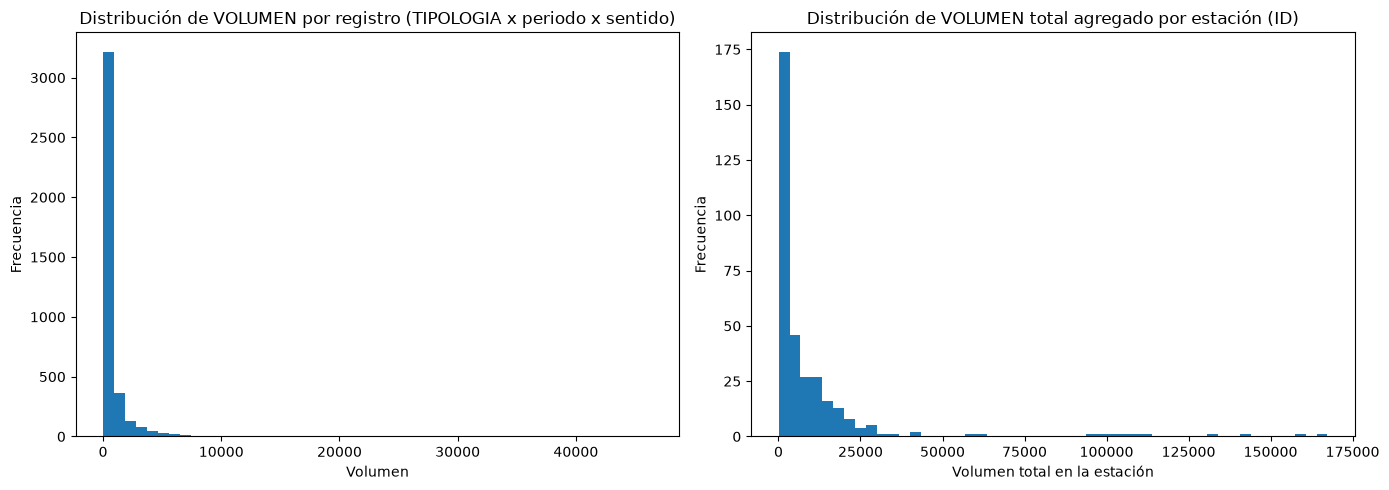

In [11]:
volumen_por_id = bd.groupby("ID")["VOLUMEN"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(bd["VOLUMEN"], bins=50)
axes[0].set_title("Distribución de VOLUMEN por registro (TIPOLOGIA x periodo x sentido)")
axes[0].set_xlabel("Volumen")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(volumen_por_id, bins=50)
axes[1].set_title("Distribución de VOLUMEN total agregado por estación (ID)")
axes[1].set_xlabel("Volumen total en la estación")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

La distribución de `VOLUMEN` está fuertemente sesgada a la derecha (media ≈ 866, mediana = 64, máximo ≈ 46 443): unas pocas estaciones/tipologías (típicamente BRT y vías arterias con auto) concentran volúmenes muy altos, mientras la mayoría de registros (modos como bicicleta o tipologías de baja frecuencia) tienen conteos bajos. Esto es esperable dado que se mezclan tipologías muy distintas (peatones/bici vs. BRT/troncal) en la misma columna.

In [12]:
bd.groupby("TIPOLOGIA")["VOLUMEN"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False)

,count,mean,median,std,min,max
TIPOLOGIA,,,,,,
TRONCAL,44,29289.303545,35837.500000,11736.336280,10114.0,46443.000000
TPC_URBANO,270,2579.283026,2287.437500,2083.281837,0.0,9200.750000
BRT,168,2140.638889,1370.666667,2396.019956,82.0,15181.333333
MOTO,378,1123.716931,820.500000,1094.381574,2.0,7346.000000
AUTO,378,803.419312,607.000000,807.080145,0.0,6369.000000
BICICLETA EN CICLORUTA,180,526.397222,229.500000,700.429841,2.0,4187.500000
TPC_INTERMUNICIPAL,270,510.473286,0.000000,928.124945,0.0,5589.000000
BICICLETA EN CALZADA,378,141.907407,74.500000,203.131954,0.0,1598.000000
CP,378,86.788360,51.500000,96.687780,0.0,768.000000


In [13]:
volumen_por_id.head(10)

ID
BRT_10    167355.225000
BRT_3     159778.250000
BRT_2     141721.630435
BRT_1     131955.500000
BRT_8     112854.000000
BRT_9     107857.500000
BRT_5     106390.000000
BRT_11    102117.916667
BRT_4      99768.956522
BRT_6      95990.032520
Name: VOLUMEN, dtype: float64

In [14]:
print("Registros con VOLUMEN == 0:", (bd["VOLUMEN"] == 0).sum())
bd[bd["VOLUMEN"] == 0]["TIPOLOGIA"].value_counts()

Registros con VOLUMEN == 0: 560


TIPOLOGIA
TPC_INTERMUNICIPAL      158
ESPECIAL OCUPADO        126
TAXI OCUPADO            124
CG                       77
TPC_URBANO               32
ESCOLAR                  31
BICICLETA EN CALZADA      6
CP                        5
AUTO                      1
Name: count, dtype: int64

**Hallazgos de distribución:**
- El volumen varía en órdenes de magnitud distintos según `TIPOLOGIA` (BRT/TRONCAL con miles de vehículos-equivalente vs. bicicleta/taxi con decenas), por lo que cualquier análisis o modelo posterior debe segmentar por tipología en vez de tratar `VOLUMEN` como una sola población homogénea.
- Las 10 estaciones con mayor volumen total concentran una fracción importante de la demanda medida; conviene revisarlas primero al validar la red de simulación en Usaquén.
- 560 registros tienen `VOLUMEN == 0` (o valores muy cercanos), concentrados en tipologías de baja frecuencia (p. ej. escolar, especial ocupado, taxi) — no parecen errores sino conteos reales de modos poco usados en ciertos puntos/periodos, pero vale la pena confirmarlo con el equipo antes de excluirlos de futuros modelos.

## 5. Resumen de hallazgos iniciales

- **Estructura**: `BD` tiene 3956 registros × 7 columnas (`TIPOLOGIA`, `ID`, `LOCALIZACIÓN`, `EODI`, `PERIODO`, `SENTIDO`, `VOLUMEN`), sin fechas explícitas, solo franja AM/PM. El diccionario de datos (`DICC`) documenta bien los rangos esperados por columna.
- **Calidad**: no hay valores nulos. Existen 3 filas duplicadas exactas (todas BRT, periodo AM, sentido INGRESO) que deben depurarse o validarse con la fuente. Los valores categóricos son consistentes con el diccionario, salvo abreviaciones (`CG`, `CP`) y una categoría adicional no documentada (`TRONCAL`).
- **Consistencia temporal**: ~28% de las estaciones (95 de 336) no tiene registros en ambos periodos AM y PM, lo cual limita las comparaciones AM vs PM para ese subconjunto. Cada estación (`ID`) mapea de forma consistente a una sola `LOCALIZACIÓN`.
- **Distribución**: el volumen está muy sesgado y depende fuertemente de la tipología vehicular; el análisis y modelado posteriores deben segmentarse por `TIPOLOGIA` en vez de usar `VOLUMEN` de forma agregada.

**Pendientes / preguntas para el equipo:**
1. Confirmar con la fuente si las 3 filas duplicadas en BRT son error de digitación o mediciones válidas repetidas.
2. Decidir el tratamiento de las 95 estaciones sin cobertura AM+PM (excluir, imputar, o dejarlas solo para el periodo disponible).
3. Cruzar este dataset con la exploración de la Encuesta de Movilidad 2023 (F1.2 / issue #2), dado que ambos son insumos co-requisito para F1.5 (alcance geográfico y temporal).